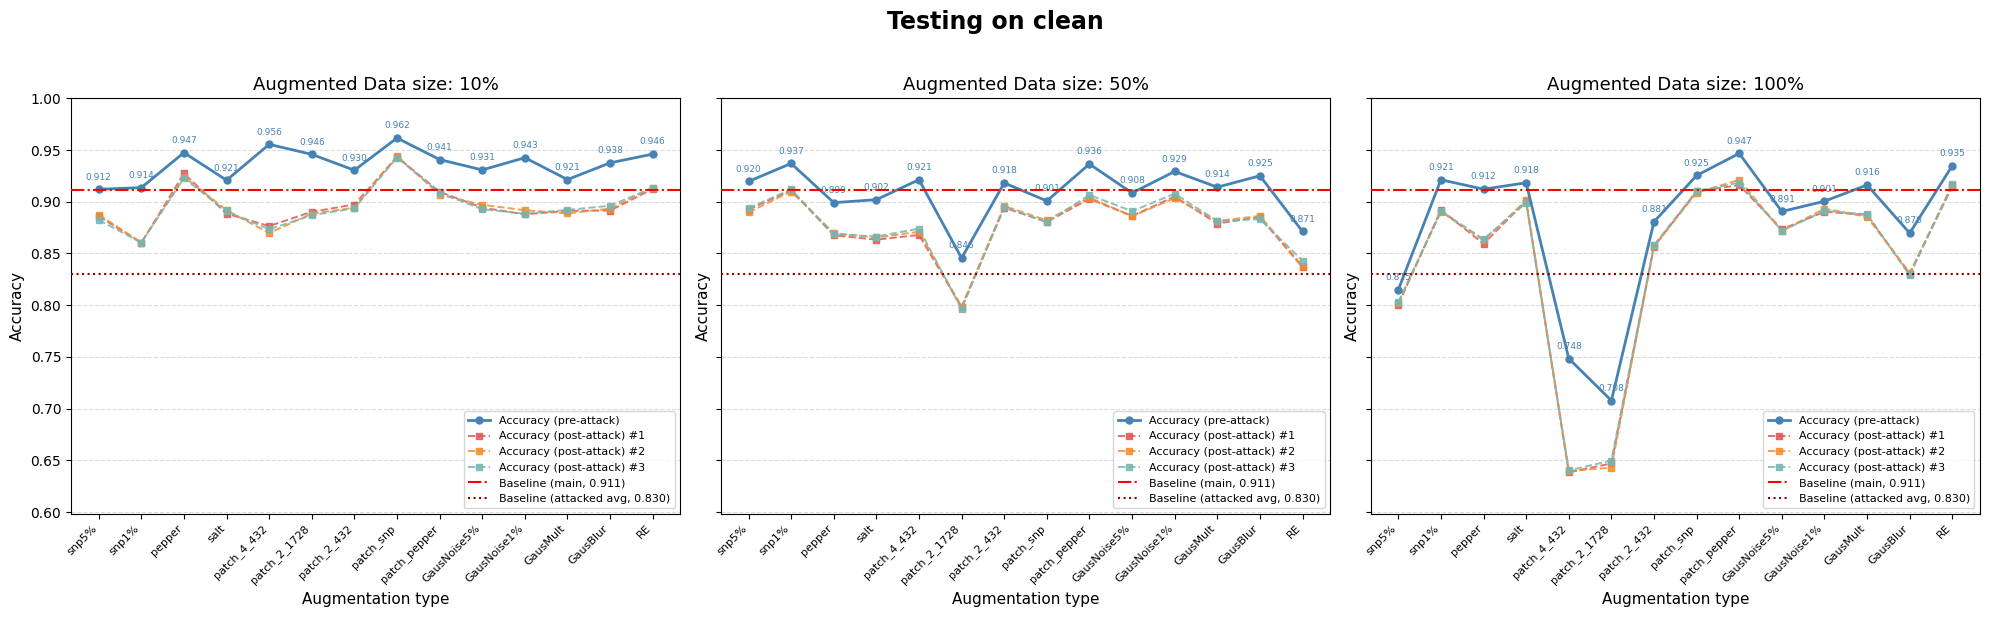

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import glob, os

df10  = pd.read_csv('../results_testing/test_metrics_10%_aug.csv')
df50  = pd.read_csv('../results_testing/test_metrics_50%_aug.csv')
df100 = pd.read_csv('../results_testing/test_metrics_100%_aug.csv')

for df in [df10, df50, df100]:
    df.columns = df.columns.str.strip()
    if df.columns[0] not in ("Augmentation", "augmentation"):
        df.drop(columns=df.columns[0], inplace=True)

# capture baseline accuracies before dropping them from the dataframes
baseline_main = float(df10.loc[df10["Augmentation"] == "baseline", "Accuracy"].iloc[0])

_extra10_paths = sorted(glob.glob("../results10c50g/10perc/*.csv"))
_extra10_baselines = []
for _p in _extra10_paths:
    _d = pd.read_csv(_p)
    _d.columns = _d.columns.str.strip()
    _row = _d[_d["Augmentation"] == "baseline"]
    if not _row.empty:
        _extra10_baselines.append(float(_row["Accuracy"].iloc[0]))
baseline_extra_avg = float(np.mean(_extra10_baselines))

for df in [df10, df50, df100]:
    df.drop(df[df["Augmentation"] == "baseline"].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

canonical_order = df10["Augmentation"].tolist()
def reorder(df):
    return (df.set_index("Augmentation")
              .reindex(canonical_order)
              .reset_index()
              .dropna(subset=["Accuracy"])
              .reset_index(drop=True))
df50  = reorder(df50)
df100 = reorder(df100)

def load_extra(folder_glob):
    paths = sorted(glob.glob(folder_glob))
    dfs = []
    for p in paths:
        d = pd.read_csv(p)
        d.columns = d.columns.str.strip()
        if d.columns[0] not in ("Augmentation", "augmentation"):
            d.drop(columns=d.columns[0], inplace=True)
        d = d[d["Augmentation"] != "baseline"].reset_index(drop=True)
        dfs.append((os.path.basename(p), d))
    return dfs

extra10  = load_extra("../results10c50g/10perc/*.csv")
extra50  = load_extra("../results10c50g/50perc/*.csv")
extra100 = load_extra("../results10c50g/100perc/*.csv")

def align_accuracy(main_df, extra_df):
    acc_map = dict(zip(extra_df["Augmentation"], extra_df["Accuracy"]))
    return np.array([acc_map.get(aug, np.nan) for aug in main_df["Augmentation"]])

aug_rename = {
    "random_erasing":            "RE",
    "gaussian_blur":             "GausBlur",
    "gaussian_noise_mult":       "GausMult",
    "gaussian_noise_greyscale_1%": "GausNoise1%",
    "gaussian_noise_greyscale":  "GausNoise5%",
    "pepper-only_5%":            "pepper",
    "salt-only_5%":              "salt",
    "patch_16x16_18_p_fillup":   "patch_pepper",
    "patch_16x16_18_snp_fillup": "patch_snp",
    "patch_2x2_432":             "patch_2_432",
    "patch_2x2_1728":            "patch_2_1728",
    "patch_4x4_432":             "patch_4_432",
    "snp_1%":                    "snp1%",
    "snp_5%(default)":           "snp5%",
}

for df in [df10, df50, df100]:
    df["Augmentation"] = df["Augmentation"].map(lambda v: aug_rename.get(v, v))
canonical_order = df10["Augmentation"].tolist()

extra10  = [(n, d.assign(Augmentation=d["Augmentation"].map(lambda v: aug_rename.get(v, v)))) for n, d in extra10]
extra50  = [(n, d.assign(Augmentation=d["Augmentation"].map(lambda v: aug_rename.get(v, v)))) for n, d in extra50]
extra100 = [(n, d.assign(Augmentation=d["Augmentation"].map(lambda v: aug_rename.get(v, v)))) for n, d in extra100]

datasets = [
    ("10%",  df10,  extra10),
    ("50%",  df50,  extra50),
    ("100%", df100, extra100),
]

dot_colors  = ["#e15759", "#f28e2b", "#76b7b2"]
dot_labels  = ["Accuracy (post-attack) #1", "Accuracy (post-attack) #2", "Accuracy (post-attack) #3"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle("Testing on clean", fontsize=17, fontweight="bold", y=1.02)

for ax, (label, main_df, extras) in zip(axes, datasets):
    aug_labels = main_df["Augmentation"].tolist()
    accuracy   = main_df["Accuracy"].tolist()
    x          = np.arange(len(aug_labels))

    ax.plot(x, accuracy, marker="o", linewidth=2, markersize=5,
            color="steelblue", label="Accuracy (pre-attack)", zorder=3)

    for xi, yi in zip(x, accuracy):
        ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=6.5, color="steelblue")

    for i, (fname, edf) in enumerate(extras):
        aligned = align_accuracy(main_df, edf)
        ax.plot(x, aligned, linestyle="--", marker="s", markersize=4,
                linewidth=1.4, color=dot_colors[i],
                label=dot_labels[i], zorder=2, alpha=0.85)

    ax.axhline(baseline_main, color="red", linewidth=1.5, linestyle="-.",
               label=f"Baseline (main, {baseline_main:.3f})", zorder=4)
    ax.axhline(baseline_extra_avg, color="darkred", linewidth=1.5, linestyle=":",
               label=f"Baseline (attacked avg, {baseline_extra_avg:.3f})", zorder=4)

    ax.set_title(f"Augmented Data size: {label}", fontsize=13)
    ax.set_xlabel("Augmentation type", fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(aug_labels, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    all_vals = [v for v in accuracy]
    for _, edf in extras:
        all_vals += align_accuracy(main_df, edf)[~np.isnan(align_accuracy(main_df, edf))].tolist()
    ax.set_ylim(max(0, min(all_vals) - 0.04), min(1.0, max(all_vals) + 0.07))
    ax.grid(axis="y", linestyle="--", alpha=0.45)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("testing_on_clean.png", dpi=150, bbox_inches="tight")
plt.show()

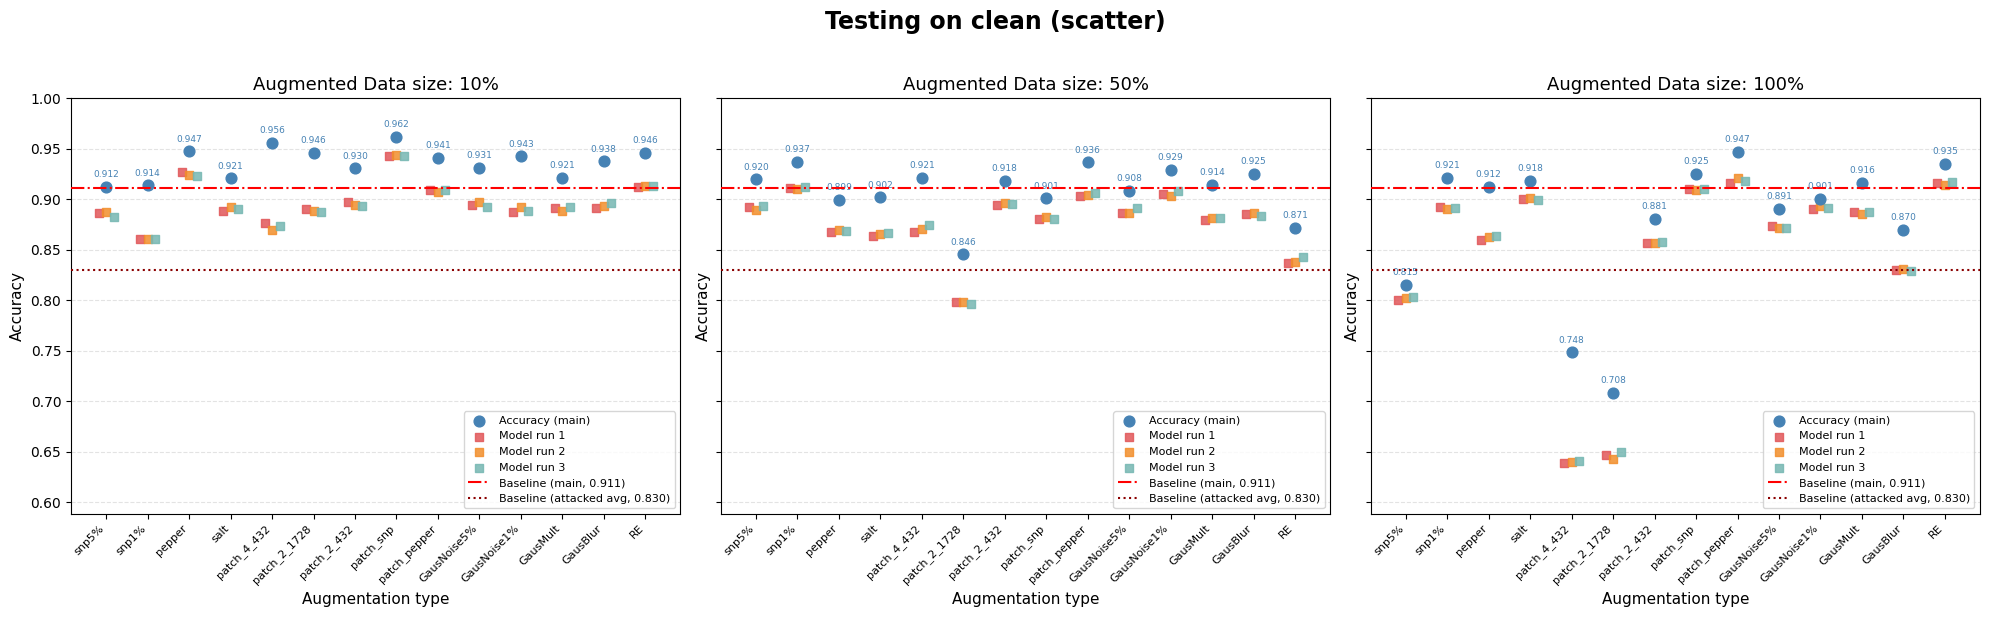

In [2]:
dot_colors_lollipop = ["#e15759", "#f28e2b", "#76b7b2"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle("Testing on clean (scatter)", fontsize=17, fontweight="bold", y=1.02)

for ax, (label, main_df, extras) in zip(axes, datasets):
    aug_labels = main_df["Augmentation"].tolist()
    accuracy   = main_df["Accuracy"].tolist()
    x          = np.arange(len(aug_labels))

    all_vals = list(accuracy)
    for _, edf in extras:
        vals = align_accuracy(main_df, edf)
        all_vals += vals[~np.isnan(vals)].tolist()
    y_floor = max(0.0, min(all_vals) - 0.05)

    ax.scatter(x, accuracy, color="steelblue", s=60, zorder=4,
               label="Accuracy (main)")

    for xi, yi in zip(x, accuracy):
        ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=6.5, color="steelblue")

    offsets = [-0.18, 0.0, 0.18]  # slight horizontal jitter so dots don't stack
    for i, (fname, edf) in enumerate(extras):
        aligned = align_accuracy(main_df, edf)
        mask = ~np.isnan(aligned)
        ax.scatter(x[mask] + offsets[i], aligned[mask],
                   color=dot_colors_lollipop[i], s=30, marker="s",
                   zorder=3, alpha=0.85,
                   label=f"Model run {i+1}")

    ax.axhline(baseline_main, color="red", linewidth=1.5, linestyle="-.",
               label=f"Baseline (main, {baseline_main:.3f})", zorder=5)
    ax.axhline(baseline_extra_avg, color="darkred", linewidth=1.5, linestyle=":",
               label=f"Baseline (attacked avg, {baseline_extra_avg:.3f})", zorder=5)

    ax.set_title(f"Augmented Data size: {label}", fontsize=13)
    ax.set_xlabel("Augmentation type", fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(aug_labels, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.set_ylim(y_floor, min(1.0, max(all_vals) + 0.07))
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("testing_on_clean_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

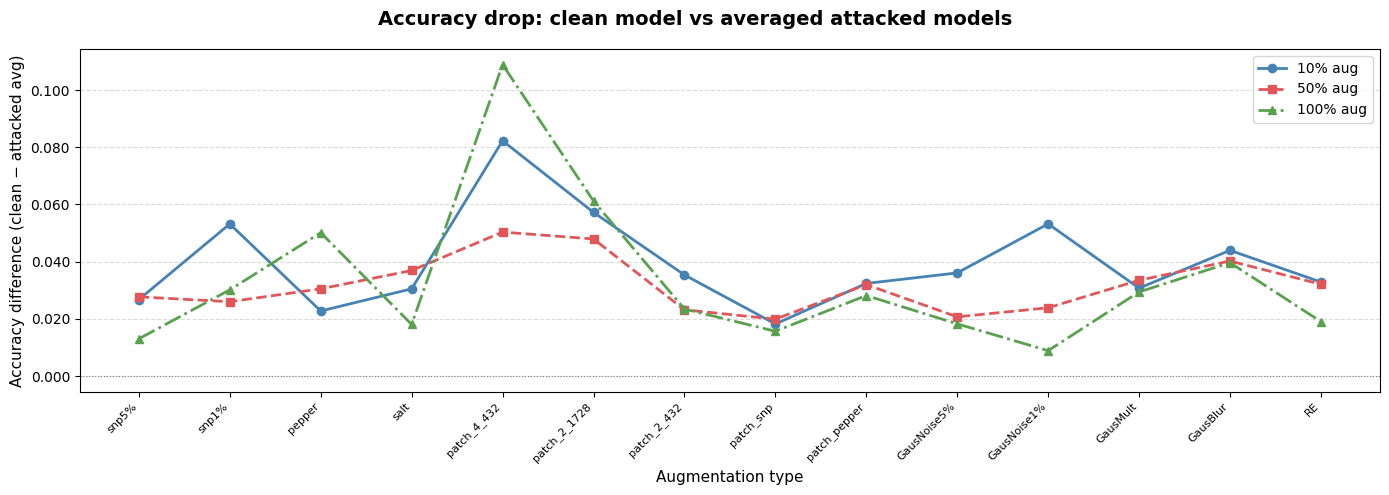

In [3]:
ref_augs = df10['Augmentation'].tolist()
x = np.arange(len(ref_augs))

def diff_line(main_df, extras, ref_augs):
    main_map = dict(zip(main_df["Augmentation"], main_df["Accuracy"]))
    stacked = []
    for _, edf in extras:
        acc_map = dict(zip(edf["Augmentation"], edf["Accuracy"]))
        stacked.append([acc_map.get(aug, np.nan) for aug in ref_augs])
    stacked = np.array(stacked)
    avg_extra = np.nanmean(stacked, axis=0)
    all_nan = np.all(np.isnan(stacked), axis=0)
    avg_extra[all_nan] = np.nan

    main_acc = np.array([main_map.get(aug, np.nan) for aug in ref_augs])
    diff = main_acc - avg_extra
    diff[np.isnan(main_acc) | np.isnan(avg_extra)] = np.nan
    return diff

diff10  = diff_line(df10,  extra10,  ref_augs)
diff50  = diff_line(df50,  extra50,  ref_augs)
diff100 = diff_line(df100, extra100, ref_augs)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Accuracy drop: clean model vs averaged attacked models",
             fontsize=14, fontweight="bold")

line_styles = [
    dict(color="steelblue",  linestyle="-",  marker="o", label="10% aug"),
    dict(color="#e15759",    linestyle="--", marker="s", label="50% aug"),
    dict(color="#59a14f",    linestyle="-.", marker="^", label="100% aug"),
]

for diff, style in zip([diff10, diff50, diff100], line_styles):
    ax.plot(x, diff, linewidth=2, markersize=6, **style)

ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
ax.set_xticks(x)
ax.set_xticklabels(ref_augs, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Augmentation type", fontsize=11)
ax.set_ylabel("Accuracy difference (clean − attacked avg)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("accuracy_drop.png", dpi=150, bbox_inches="tight")
plt.show()

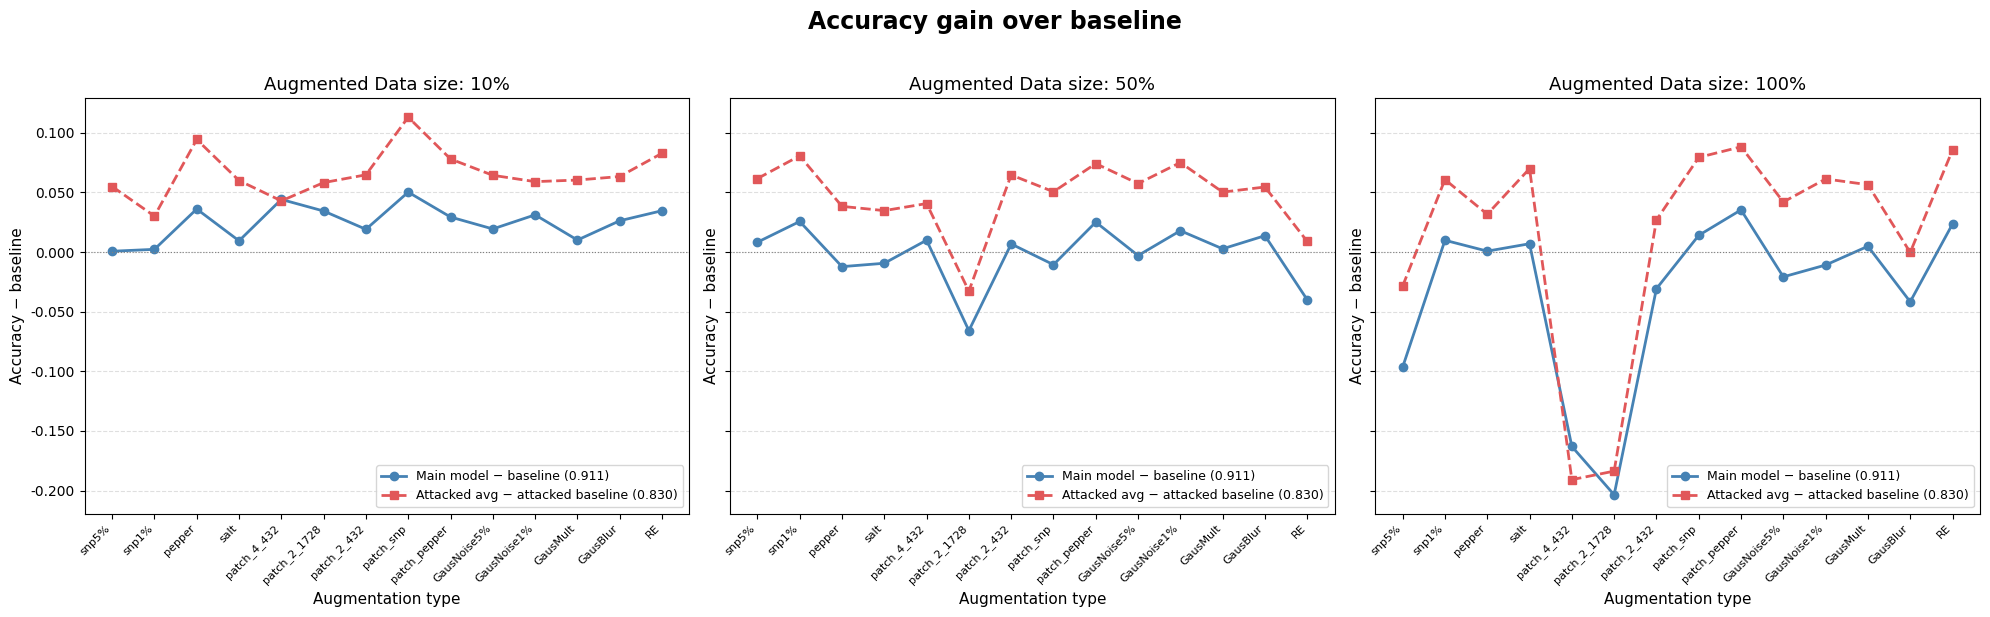

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle("Accuracy gain over baseline", fontsize=17, fontweight="bold", y=1.02)

for ax, (label, main_df, extras) in zip(axes, datasets):
    aug_labels = main_df["Augmentation"].tolist()
    x          = np.arange(len(aug_labels))

    diff_main = np.array(main_df["Accuracy"].tolist()) - baseline_main

    stacked = np.array([align_accuracy(main_df, edf) for _, edf in extras])
    mean_extra = np.nanmean(stacked, axis=0)
    diff_extra = mean_extra - baseline_extra_avg

    ax.plot(x, diff_main, marker="o", linewidth=2, markersize=6,
            color="steelblue", label=f"Main model − baseline ({baseline_main:.3f})")
    ax.plot(x, diff_extra, marker="s", linewidth=2, markersize=6,
            linestyle="--", color="#e15759",
            label=f"Attacked avg − attacked baseline ({baseline_extra_avg:.3f})")

    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")

    ax.set_title(f"Augmented Data size: {label}", fontsize=13)
    ax.set_xlabel("Augmentation type", fontsize=11)
    ax.set_ylabel("Accuracy − baseline", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(aug_labels, rotation=45, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("accuracy_gain_over_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

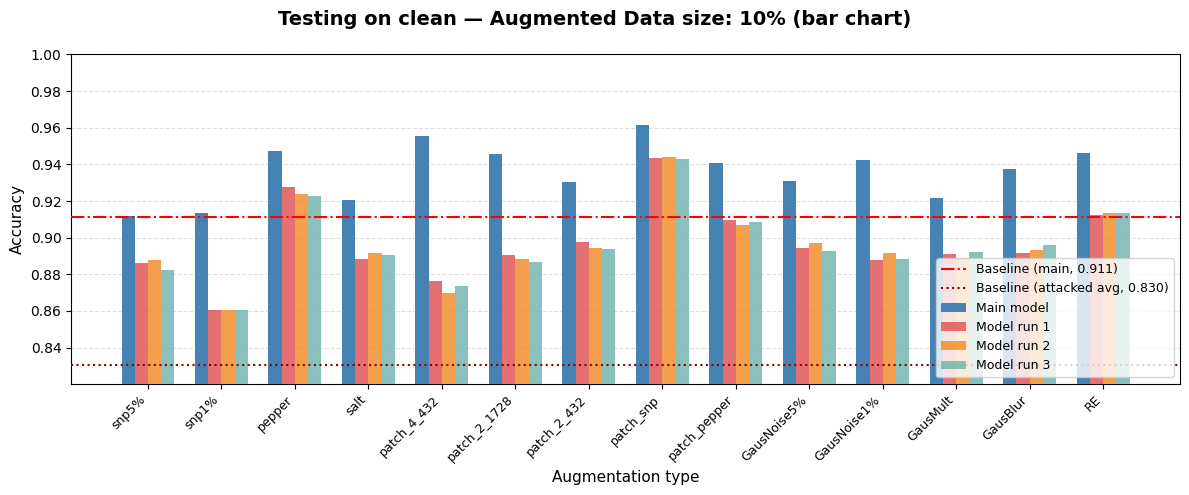

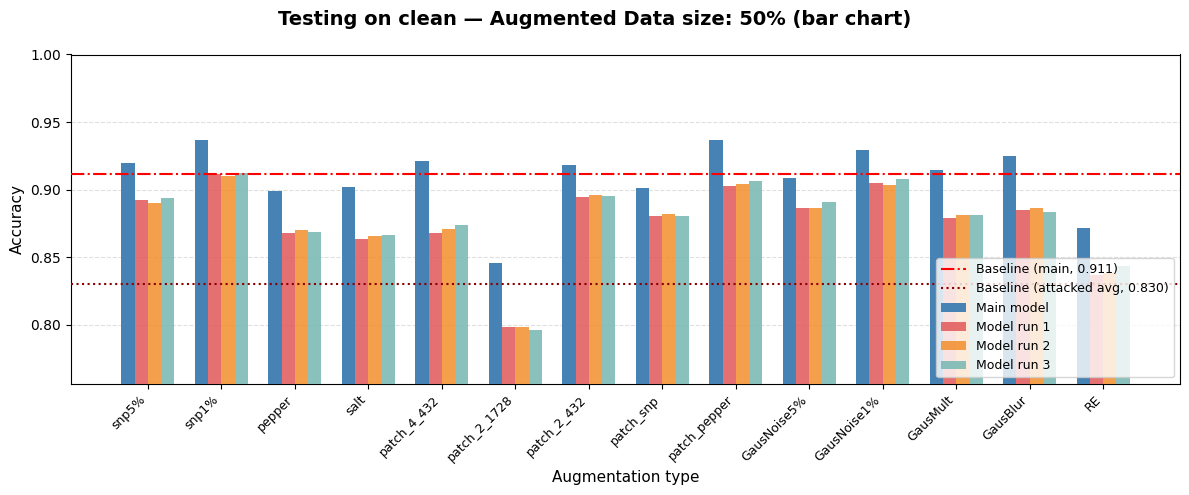

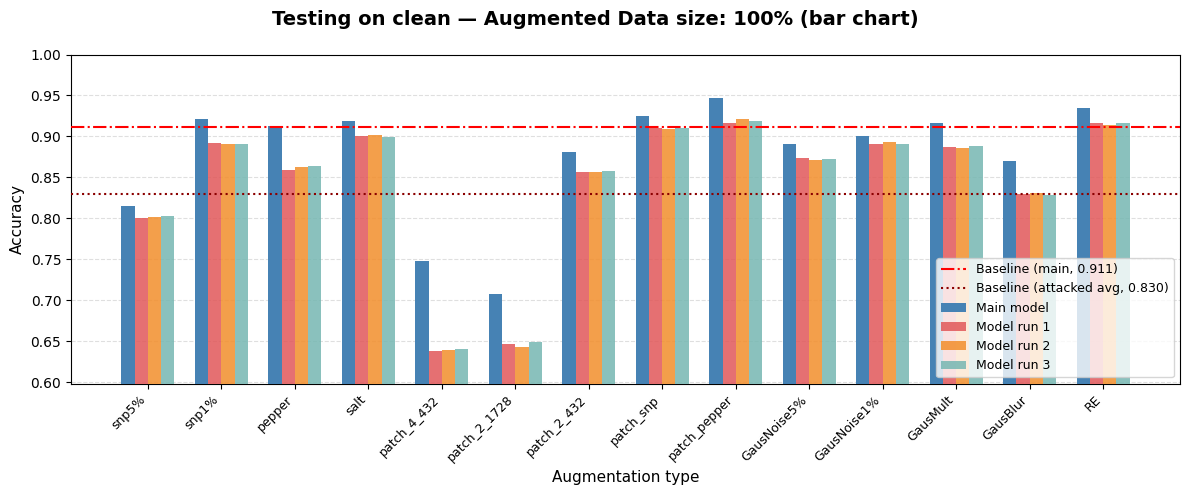

In [5]:
bar_colors = ["steelblue", "#e15759", "#f28e2b", "#76b7b2"]
bar_labels  = ["Main model", "Model run 1", "Model run 2", "Model run 3"]
bar_width   = 0.18
offsets     = [-0.27, -0.09, 0.09, 0.27]

for label, main_df, extras in datasets:
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle(f"Testing on clean — Augmented Data size: {label} (bar chart)",
                 fontsize=14, fontweight="bold")

    aug_labels = main_df["Augmentation"].tolist()
    accuracy   = main_df["Accuracy"].tolist()
    x          = np.arange(len(aug_labels))

    ax.bar(x + offsets[0], accuracy, width=bar_width,
           color=bar_colors[0], label=bar_labels[0], zorder=3)

    for i, (fname, edf) in enumerate(extras):
        aligned = align_accuracy(main_df, edf)
        vals = np.where(np.isnan(aligned), 0, aligned)
        ax.bar(x + offsets[i + 1], vals, width=bar_width,
               color=bar_colors[i + 1], label=bar_labels[i + 1],
               alpha=0.85, zorder=3)

    ax.axhline(baseline_main, color="red", linewidth=1.5, linestyle="-.",
               label=f"Baseline (main, {baseline_main:.3f})", zorder=4)
    ax.axhline(baseline_extra_avg, color="darkred", linewidth=1.5, linestyle=":",
               label=f"Baseline (attacked avg, {baseline_extra_avg:.3f})", zorder=4)

    ax.set_xlabel("Augmentation type", fontsize=11)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(aug_labels, rotation=45, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    all_vals = list(accuracy)
    for _, edf in extras:
        v = align_accuracy(main_df, edf)
        all_vals += v[~np.isnan(v)].tolist()
    ax.set_ylim(max(0, min(all_vals) - 0.04), min(1.0, max(all_vals) + 0.07))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend(fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.savefig(f"testing_on_clean_bar_{label.replace('%','pct')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

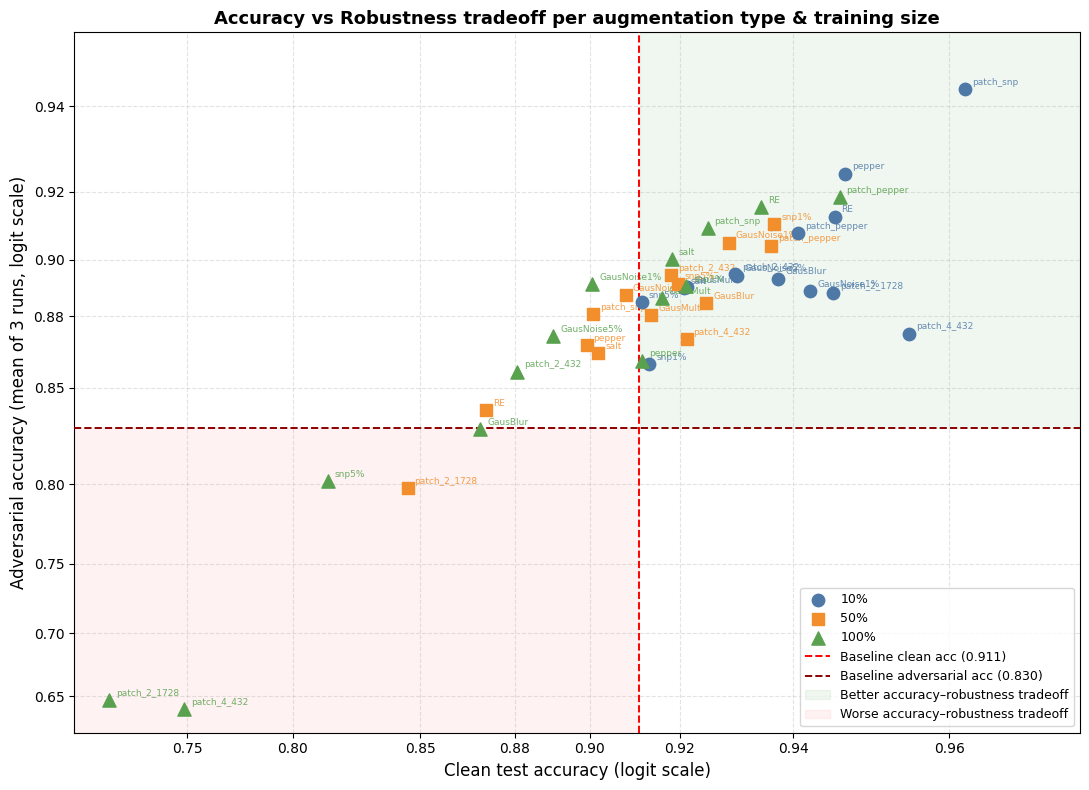

In [6]:
size_styles = {
    "10%":  dict(color="#4e79a7", marker="o", s=80),
    "50%":  dict(color="#f28e2b", marker="s", s=80),
    "100%": dict(color="#59a14f", marker="^", s=90),
}

fig, ax = plt.subplots(figsize=(11, 8))

all_x, all_y = [], []

for label, main_df, extras in datasets:
    aug_labels = main_df["Augmentation"].tolist()
    main_acc   = main_df["Accuracy"].values

    stacked = np.array([align_accuracy(main_df, edf) for _, edf in extras])
    mean_adv = np.nanmean(stacked, axis=0)

    style = size_styles[label]
    for i, aug in enumerate(aug_labels):
        x_val = main_acc[i]
        y_val = mean_adv[i]
        if np.isnan(y_val):
            continue
        ax.scatter(x_val, y_val, zorder=4, **style,
                   label=label if i == 0 else "_nolegend_")
        ax.annotate(aug, (x_val, y_val),
                    textcoords="offset points", xytext=(5, 3),
                    fontsize=6.5, color=style["color"], alpha=0.85)
        all_x.append(x_val)
        all_y.append(y_val)

ax.set_xscale('logit')
ax.set_yscale('logit')

_eps = 1e-4
x_lo = max(_eps, min(all_x) - 0.02)
x_hi = min(1 - _eps, max(all_x) + 0.01)
y_lo = max(_eps, min(all_y) - 0.02)
y_hi = min(1 - _eps, max(all_y) + 0.01)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

x_ticks = [v for v in [0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99]
           if x_lo <= v <= x_hi]
y_ticks = [v for v in [0.65, 0.70, 0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99]
           if y_lo <= v <= y_hi]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax.axvline(baseline_main, color="red", linewidth=1.4, linestyle="--",
           label=f"Baseline clean acc ({baseline_main:.3f})", zorder=3)
ax.axhline(baseline_extra_avg, color="darkred", linewidth=1.4, linestyle="--",
           label=f"Baseline adversarial acc ({baseline_extra_avg:.3f})", zorder=3)

x_fill = np.linspace(baseline_main + _eps, x_hi, 300)
ax.fill_between(x_fill,
                baseline_extra_avg, y_hi,
                color="green", alpha=0.06,
                label="Better accuracy–robustness tradeoff")
x_fill2 = np.linspace(x_lo, baseline_main - _eps, 300)
ax.fill_between(x_fill2,
                y_lo, baseline_extra_avg,
                color="red", alpha=0.05,
                label="Worse accuracy–robustness tradeoff")

ax.set_xlabel("Clean test accuracy (logit scale)", fontsize=12)
ax.set_ylabel("Adversarial accuracy (mean of 3 runs, logit scale)", fontsize=12)
ax.set_title("Accuracy vs Robustness tradeoff per augmentation type & training size",
             fontsize=13, fontweight="bold")
ax.grid(linestyle="--", alpha=0.35)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("accuracy_vs_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

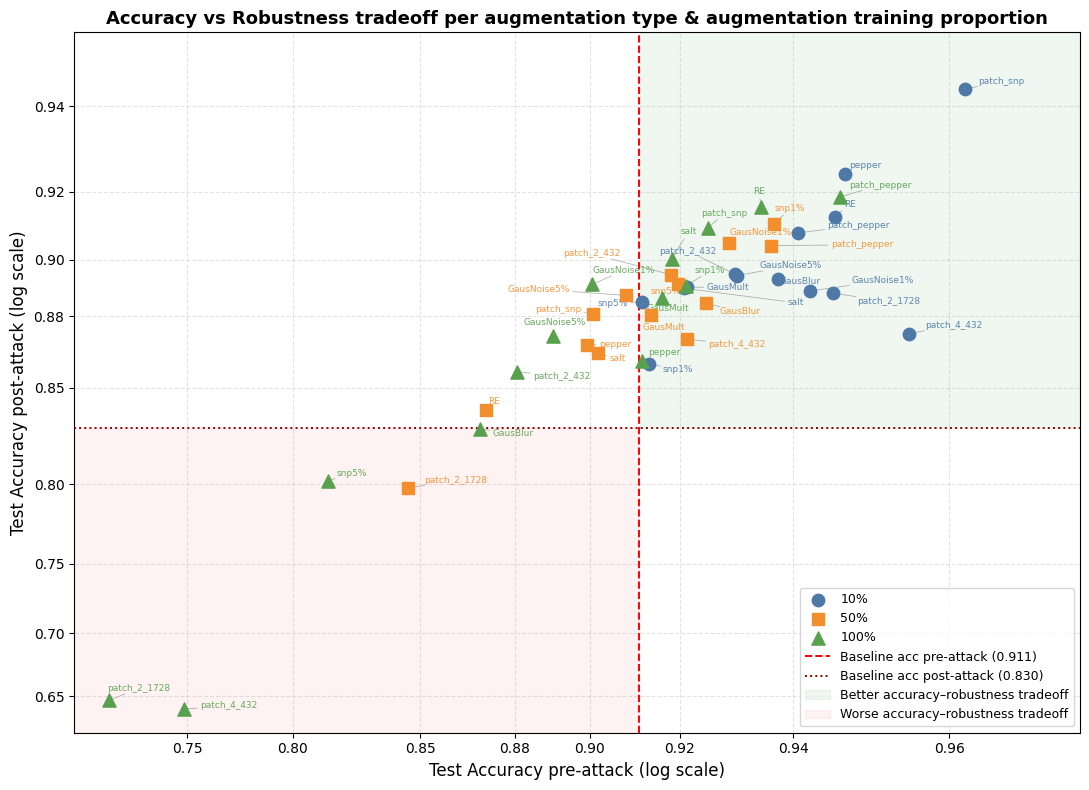

In [7]:
from adjustText import adjust_text

size_styles = {
    "10%":  dict(color="#4e79a7", marker="o", s=80),
    "50%":  dict(color="#f28e2b", marker="s", s=80),
    "100%": dict(color="#59a14f", marker="^", s=90),
}

fig, ax = plt.subplots(figsize=(11, 8))

all_x, all_y, texts = [], [], []

for label, main_df, extras in datasets:
    aug_labels = main_df["Augmentation"].tolist()
    main_acc   = main_df["Accuracy"].values

    stacked  = np.array([align_accuracy(main_df, edf) for _, edf in extras])
    mean_adv = np.nanmean(stacked, axis=0)

    style = size_styles[label]
    for i, aug in enumerate(aug_labels):
        x_val = main_acc[i]
        y_val = mean_adv[i]
        if np.isnan(y_val):
            continue
        ax.scatter(x_val, y_val, zorder=4, **style,
                   label=label if i == 0 else "_nolegend_")
        t = ax.text(x_val, y_val, aug, fontsize=6.5,
                    color=style["color"], alpha=0.9)
        texts.append(t)
        all_x.append(x_val)
        all_y.append(y_val)

ax.set_xscale('logit')
ax.set_yscale('logit')

_eps = 1e-4
x_lo = max(_eps, min(all_x) - 0.02)
x_hi = min(1 - _eps, max(all_x) + 0.01)
y_lo = max(_eps, min(all_y) - 0.02)
y_hi = min(1 - _eps, max(all_y) + 0.01)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

x_ticks = [v for v in [0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99]
           if x_lo <= v <= x_hi]
y_ticks = [v for v in [0.65, 0.70, 0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99]
           if y_lo <= v <= y_hi]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax.axvline(baseline_main, color="red", linewidth=1.4, linestyle="--",
           label=f"Baseline acc pre-attack ({baseline_main:.3f})", zorder=3)
ax.axhline(baseline_extra_avg, color="darkred", linewidth=1.4, linestyle=":",
           label=f"Baseline acc post-attack ({baseline_extra_avg:.3f})", zorder=3)

x_fill = np.linspace(baseline_main + _eps, x_hi, 300)
ax.fill_between(x_fill, baseline_extra_avg, y_hi,
                color="green", alpha=0.06, label="Better accuracy–robustness tradeoff")
x_fill2 = np.linspace(x_lo, baseline_main - _eps, 300)
ax.fill_between(x_fill2, y_lo, baseline_extra_avg,
                color="red", alpha=0.05, label="Worse accuracy–robustness tradeoff")

adjust_text(
    texts,
    ax=ax,
    expand=(1.3, 1.5),
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.6, alpha=0.6),
)

ax.set_xlabel("Test Accuracy pre-attack (log scale)", fontsize=12)
ax.set_ylabel("Test Accuracy post-attack (log scale)", fontsize=12)
ax.set_title("Accuracy vs Robustness tradeoff per augmentation type & augmentation training proportion",
             fontsize=13, fontweight="bold")
ax.grid(linestyle="--", alpha=0.35)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("accuracy_vs_robustness_nolap.png", dpi=150, bbox_inches="tight")
plt.show()

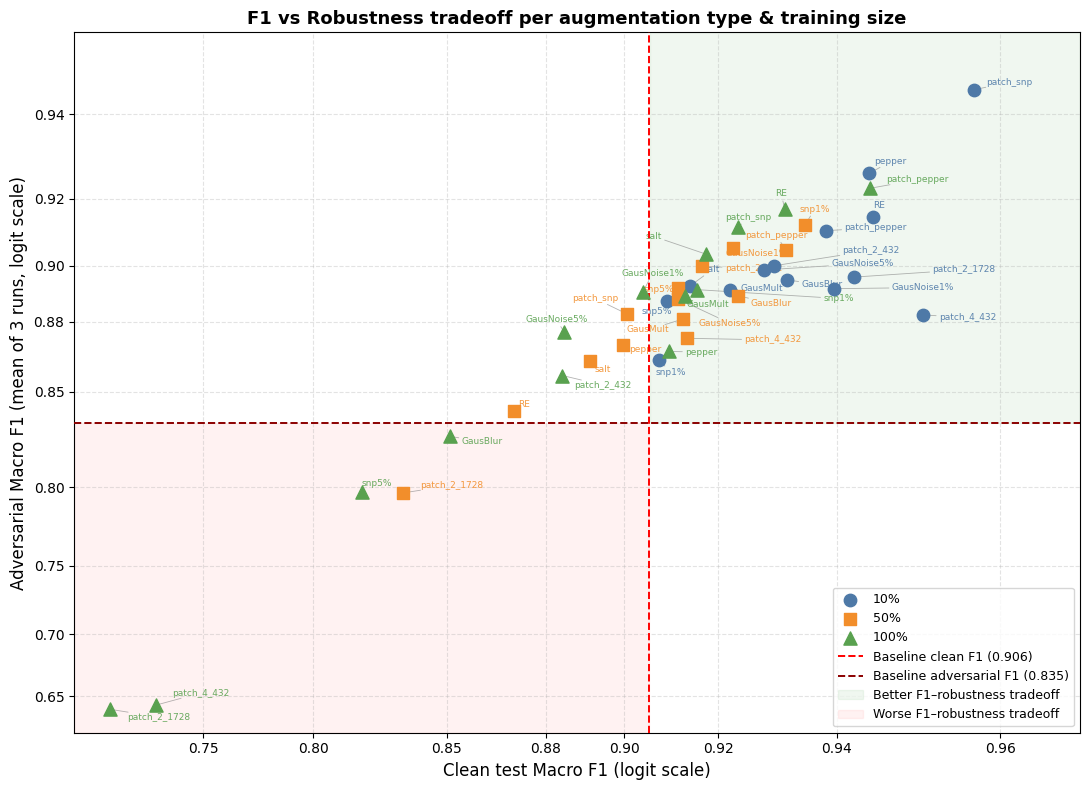

In [8]:
_df10_raw  = pd.read_csv('../results_testing/test_metrics_10%_aug.csv')
_df10_raw.columns = _df10_raw.columns.str.strip()
if _df10_raw.columns[0] not in ("Augmentation", "augmentation"):
    _df10_raw.drop(columns=_df10_raw.columns[0], inplace=True)

baseline_main_f1 = float(
    _df10_raw.loc[_df10_raw["Augmentation"] == "baseline", "Macro_F1"].iloc[0]
)

_extra10_f1_baselines = []
for _p in sorted(glob.glob("../results10c50g/10perc/*.csv")):
    _d = pd.read_csv(_p); _d.columns = _d.columns.str.strip()
    _row = _d[_d["Augmentation"] == "baseline"]
    if not _row.empty and "Macro_F1" in _d.columns:
        _extra10_f1_baselines.append(float(_row["Macro_F1"].iloc[0]))
baseline_extra_avg_f1 = float(np.mean(_extra10_f1_baselines))

def align_f1(main_df, extra_df):
    f1_map = dict(zip(extra_df["Augmentation"], extra_df["Macro_F1"]))
    return np.array([f1_map.get(aug, np.nan) for aug in main_df["Augmentation"]])

size_styles = {
    "10%":  dict(color="#4e79a7", marker="o", s=80),
    "50%":  dict(color="#f28e2b", marker="s", s=80),
    "100%": dict(color="#59a14f", marker="^", s=90),
}

fig, ax = plt.subplots(figsize=(11, 8))

all_x, all_y, texts = [], [], []

for label, main_df, extras in datasets:
    aug_labels = main_df["Augmentation"].tolist()
    main_f1    = main_df["Macro_F1"].values

    stacked   = np.array([align_f1(main_df, edf) for _, edf in extras])
    mean_adv  = np.nanmean(stacked, axis=0)

    style = size_styles[label]
    for i, aug in enumerate(aug_labels):
        x_val = main_f1[i]
        y_val = mean_adv[i]
        if np.isnan(y_val):
            continue
        ax.scatter(x_val, y_val, zorder=4, **style,
                   label=label if i == 0 else "_nolegend_")
        t = ax.text(x_val, y_val, aug, fontsize=6.5,
                    color=style["color"], alpha=0.9)
        texts.append(t)
        all_x.append(x_val)
        all_y.append(y_val)

ax.set_xscale('logit')
ax.set_yscale('logit')

_eps = 1e-4
x_lo = max(_eps, min(all_x) - 0.02)
x_hi = min(1 - _eps, max(all_x) + 0.01)
y_lo = max(_eps, min(all_y) - 0.02)
y_hi = min(1 - _eps, max(all_y) + 0.01)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

x_ticks = [v for v in [0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99]
           if x_lo <= v <= x_hi]
y_ticks = [v for v in [0.65, 0.70, 0.75, 0.80, 0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.98, 0.99]
           if y_lo <= v <= y_hi]
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax.axvline(baseline_main_f1, color="red", linewidth=1.4, linestyle="--",
           label=f"Baseline clean F1 ({baseline_main_f1:.3f})", zorder=3)
ax.axhline(baseline_extra_avg_f1, color="darkred", linewidth=1.4, linestyle="--",
           label=f"Baseline adversarial F1 ({baseline_extra_avg_f1:.3f})", zorder=3)

x_fill = np.linspace(baseline_main_f1 + _eps, x_hi, 300)
ax.fill_between(x_fill, baseline_extra_avg_f1, y_hi,
                color="green", alpha=0.06, label="Better F1–robustness tradeoff")
x_fill2 = np.linspace(x_lo, baseline_main_f1 - _eps, 300)
ax.fill_between(x_fill2, y_lo, baseline_extra_avg_f1,
                color="red", alpha=0.05, label="Worse F1–robustness tradeoff")

adjust_text(
    texts,
    ax=ax,
    expand=(1.3, 1.5),
    arrowprops=dict(arrowstyle="-", color="grey", lw=0.6, alpha=0.6),
)

ax.set_xlabel("Clean test Macro F1 (logit scale)", fontsize=12)
ax.set_ylabel("Adversarial Macro F1 (mean of 3 runs, logit scale)", fontsize=12)
ax.set_title("F1 vs Robustness tradeoff per augmentation type & training size",
             fontsize=13, fontweight="bold")
ax.grid(linestyle="--", alpha=0.35)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("f1_vs_robustness_nolap.png", dpi=150, bbox_inches="tight")
plt.show()